First, we need to import the libraries needed to have access to functions.py and various other libraries

In [1]:
import sys
import os

We append our to working path the ../src path, where functions.py lies

In [2]:
# need to be able to import src
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# absolute path to the src directory
src_path = os.path.abspath("../src")

# Add src directory to system path
sys.path.append(src_path)

# get the /MLCBAss1/Assignment-2 path
ass_path=sys.path[-2]

print(ass_path)

c:\Users\User\Desktop\Thesis\classical_approach


We import everything from functions.py. Also the first two line ensure that everytime we change something to functions.py, this change can be "seen" here

In [4]:
%load_ext autoreload
%autoreload 2

from functions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We will loda the dev dataset and we will print its columns. Just to make sure that nothing went wrong during the splitting

In [5]:
df=pd.read_csv('../data/dev_breast_cancer.csv')
df.columns

Index(['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'diagnosis'],
      dtype='object')

In this version of the assignment, the 'rncv_summary_results.csv' file can be found in the data directory. This file includes the results from applying the repeated nested cross validation technique on the dev data set. From this file, we select the best model. If you want to run the pipeline again or use it on a different dataset, just remove the 'rncv_summary_results.csv' file.

In [6]:
from pathlib import Path

my_file = Path("../data/rncv_summary_results.csv")
if not my_file.is_file():
    perform_rnCV(path='../data/dev_breast_cancer.csv')
else:
    print("File rncv_summary_results.csv already located")

File rncv_summary_results.csv already located


From the 'rncv_summary_results.csv' we elect our winner. The idea is pretty simple, as we count the number of metrics that each model scores the highest. Therefore, we find out that our best model is LogisticRegression, with SVM being close second as they tied in some key metrics. However, LogisticRegression reigned supreme in all the other metrics. Also, we need to consider the explainability of LogisticRegression, especially in such biological tasks, as we care not only for the final predictions but for an explaination of said predictions as well

In [8]:
df_dev=pd.read_csv('../data/dev_breast_cancer.csv')
df_complete=pd.read_csv('../data/data_cleaned.csv')
df_val=pd.read_csv('../data/val_clean_breast_cancer.csv')

[I 2025-12-15 20:58:34,311] A new study created in memory with name: Winner:LogisticRegression


The winner method is LogisticRegression with 8/9 metrics
 ALL HAIL THE KING!


[I 2025-12-15 20:58:35,165] Trial 0 finished with value: 0.5 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.0011013179006656682, 'l1_ratio': 0.3810426423125848, 'random_state': 42}. Best is trial 0 with value: 0.5.
[I 2025-12-15 20:58:36,081] Trial 1 finished with value: 0.9759029927760577 and parameters: {'penalty': 'l2', 'solver': 'saga', 'C': 0.9466304999738696, 'l1_ratio': 0.35775303888327936, 'random_state': 42}. Best is trial 1 with value: 0.9759029927760577.
[I 2025-12-15 20:58:36,969] Trial 2 finished with value: 0.9729618163054695 and parameters: {'penalty': 'l2', 'solver': 'saga', 'C': 0.7045711002581091, 'l1_ratio': 0.7537304745158458, 'random_state': 42}. Best is trial 1 with value: 0.9759029927760577.
[I 2025-12-15 20:58:37,861] Trial 3 finished with value: 0.8676470588235293 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 0.028449800761198026, 'l1_ratio': 0.25370790004888044, 'random_state': 42}. Best is trial 1 with value: 0.9759029927760577.

EARLY STOPPING: No improvement after 10 trials!
--> Best trial is 1 with value: 0.9759029927760577 and parameters: {'penalty': 'l2', 'solver': 'saga', 'C': 0.9466304999738696, 'l1_ratio': 0.35775303888327936, 'random_state': 42}

For model LogisticRegression the best parameters are {'penalty': 'l2', 'solver': 'saga', 'C': 0.9466304999738696, 'l1_ratio': 0.35775303888327936, 'random_state': 42}
Bootstrapped 95% CIs (Model trained on dev, tested on val):
Balanced Accuracy: [0.9595, 1.0000]
F1 Score       : [0.9577, 1.0000]
Precision      : [1.0000, 1.0000]
Recall         : [0.9189, 1.0000]
MCC            : [0.9395, 1.0000]
ROC AUC        : [0.9907, 1.0000]
PR AUC         : [0.9862, 1.0000]
Specificity         : 1.0000
NPV                 : 0.9863


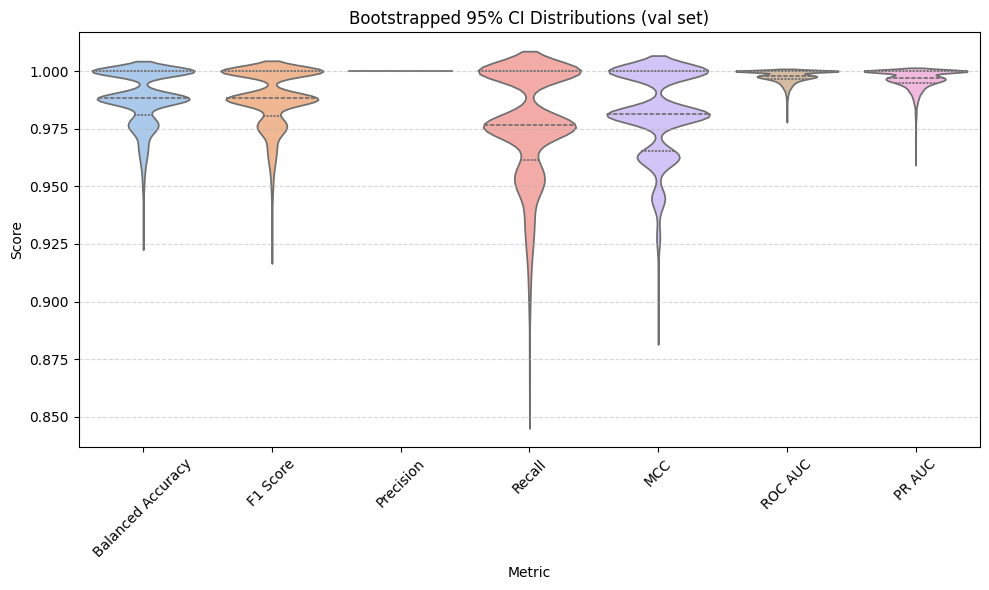

[I 2025-12-15 21:02:42,401] A new study created in memory with name: Winner:LogisticRegression
[I 2025-12-15 21:02:43,367] Trial 0 finished with value: 0.9278469915097822 and parameters: {'penalty': 'l2', 'solver': 'saga', 'C': 0.008784239599795497, 'l1_ratio': 0.9097517901661497, 'random_state': 42}. Best is trial 0 with value: 0.9278469915097822.
[I 2025-12-15 21:02:44,331] Trial 1 finished with value: 0.915171650055371 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.03171450884561541, 'l1_ratio': 0.9462057520008382, 'random_state': 42}. Best is trial 0 with value: 0.9278469915097822.
[I 2025-12-15 21:02:45,299] Trial 2 finished with value: 0.9676299398457932 and parameters: {'penalty': 'elasticnet', 'solver': 'saga', 'C': 0.4500119233369788, 'l1_ratio': 0.6446471575100203, 'random_state': 42}. Best is trial 2 with value: 0.9676299398457932.
[I 2025-12-15 21:02:46,236] Trial 3 finished with value: 0.9278469915097822 and parameters: {'penalty': 'l2', 'solver': 'saga

EARLY STOPPING: No improvement after 10 trials!
--> Best trial is 13 with value: 0.9703719084533038 and parameters: {'penalty': 'l1', 'solver': 'saga', 'C': 0.25403791132915043, 'l1_ratio': 0.27541171478673265, 'random_state': 42}

For model LogisticRegression the best parameters are {'penalty': 'l1', 'solver': 'saga', 'C': 0.25403791132915043, 'l1_ratio': 0.27541171478673265, 'random_state': 42}


In [26]:
if my_file.is_file():
    results_df=pd.read_csv("../data/rncv_summary_results.csv")

results_df=replace_column(df=results_df,to_be_replaced='Unnamed: 0',to_be_added='Model')

results_df.to_csv("../data/rncv_summary_results.csv",index=False)

if my_file.is_file():
    results_df=pd.read_csv("../data/rncv_summary_results.csv")


winner=get_winner(summary=results_df)

print(f"The winner method is {winner[0]} with {winner[1]}/{results_df.shape[1]-1} metrics\n ALL HAIL THE KING!")

df_dev=pd.read_csv('../data/dev_breast_cancer.csv')
df_complete=pd.read_csv('../data/data_cleaned.csv')
df_val=pd.read_csv('../data/val_clean_breast_cancer.csv')

tuned_winner_dev=winner_tuning(df=df_dev,winner=winner[0])

bootstrap_model(df_dev=df_dev,df_val=df_val,model=tuned_winner_dev)

tuned_winner_complete=winner_tuning(df=df_complete,winner=winner[0])

As we have tuned and evaluated the winner model with the help of bootstrapping in the above cell, we are now able to save it. Because we have applied some data cleaning(imputation,scaling,transformation etc), we will not just save the model. We will save an entire pipeline that includes all those steps, along with the final model, thus ensuring that we can infere on new unseen data withou any issues

In [28]:
save_winner(path='../data/data_cleaned.csv',winner=tuned_winner_complete,winner_name=winner[0])

Saving winner model (LogisticRegression) with name winner.pkl


Next, we will take advantage of Linear Regression explainability and we will output the 10 most influential features to classification of a tumor. This property of the model is highly desirable, as we care not only for the classification of each tumor to Benign or Malignant, but also we strive to understand which component or property of the tumor plays a vital role in its nature

       Feature  Coefficient  abs_coeff
14     area_se     1.346551   1.346551
24  area_worst     1.324220   1.324220


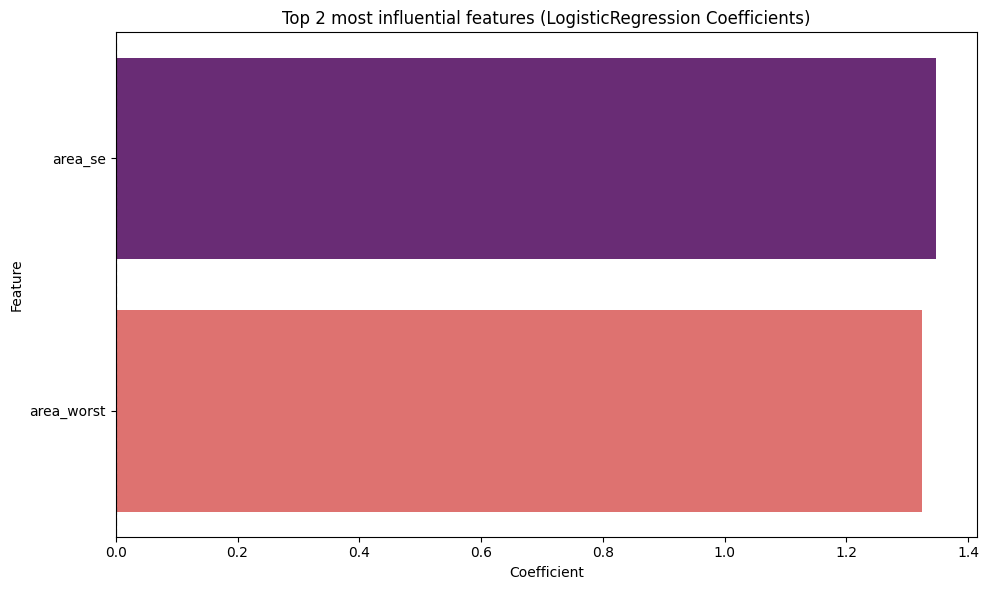

                Feature  Coefficient  abs_coeff
14              area_se     1.346551   1.346551
24           area_worst     1.324220   1.324220
8   concave points_mean     0.988615   0.988615
22        texture_worst     0.825820   0.825820


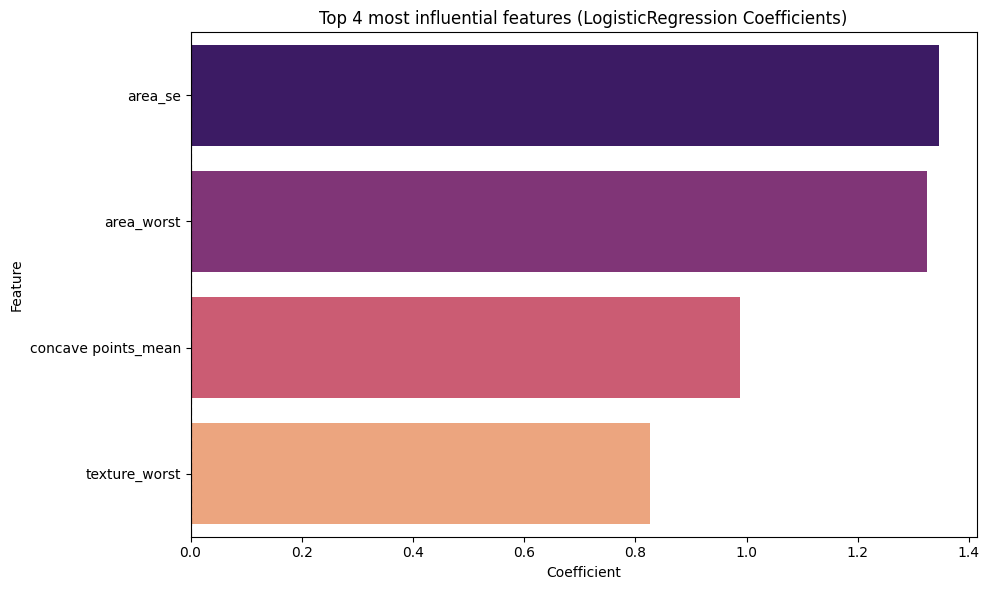

                 Feature  Coefficient  abs_coeff
14               area_se     1.346551   1.346551
24            area_worst     1.324220   1.324220
8    concave points_mean     0.988615   0.988615
22         texture_worst     0.825820   0.825820
27       concavity_worst     0.586970   0.586970
21          radius_worst     0.547358   0.547358
28  concave points_worst     0.511327   0.511327
25      smoothness_worst     0.494348   0.494348


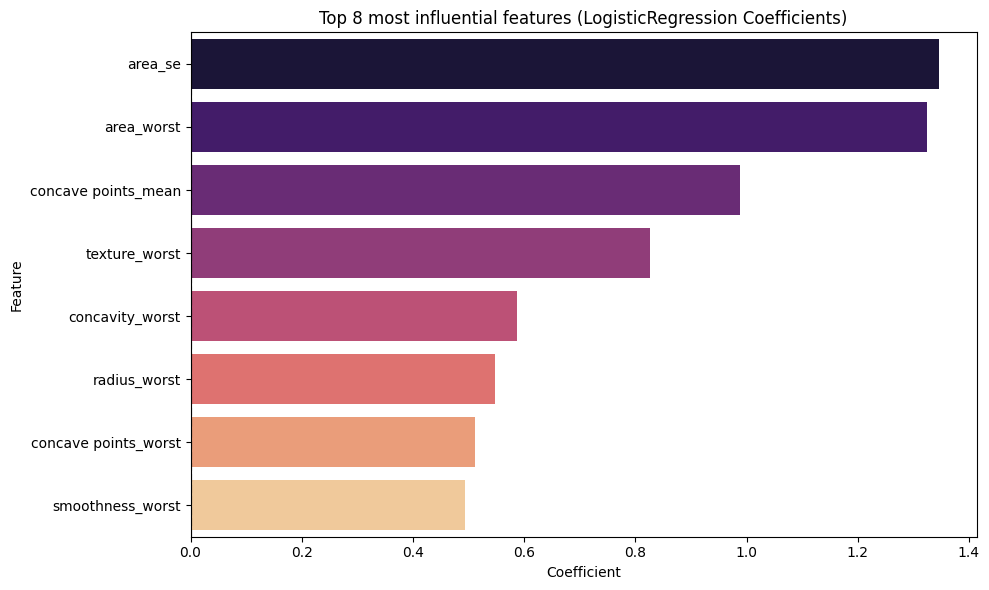

                 Feature  Coefficient  abs_coeff
14               area_se     1.346551   1.346551
24            area_worst     1.324220   1.324220
8    concave points_mean     0.988615   0.988615
22         texture_worst     0.825820   0.825820
27       concavity_worst     0.586970   0.586970
21          radius_worst     0.547358   0.547358
28  concave points_worst     0.511327   0.511327
25      smoothness_worst     0.494348   0.494348
29        symmetry_worst     0.416993   0.416993
2           texture_mean     0.312346   0.312346
19           symmetry_se    -0.234514   0.234514
16        compactness_se    -0.151014   0.151014
20  fractal_dimension_se    -0.125481   0.125481
23       perimeter_worst     0.077890   0.077890
3         perimeter_mean     0.000000   0.000000
13          perimeter_se     0.000000   0.000000


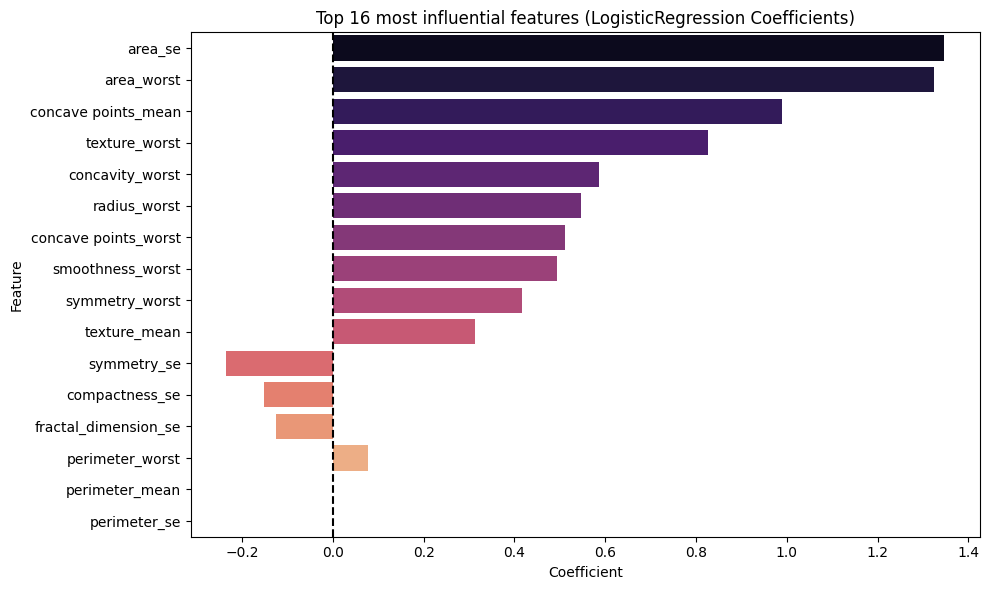

In [13]:
x,y=keep_features(data_df=df_complete)
features=x.columns

for i in range(1,5):
    cf_df=top_coefficients_winner(top=np.power(2,i),names=features)
    _,top_feats=keep_features(data_df=cf_df,target='Feature',to_drop=['id'])
    (top_feats.head(np.power(2,i))).to_csv(f"../data/top_{np.power(2,i)}_features.csv",index=False)


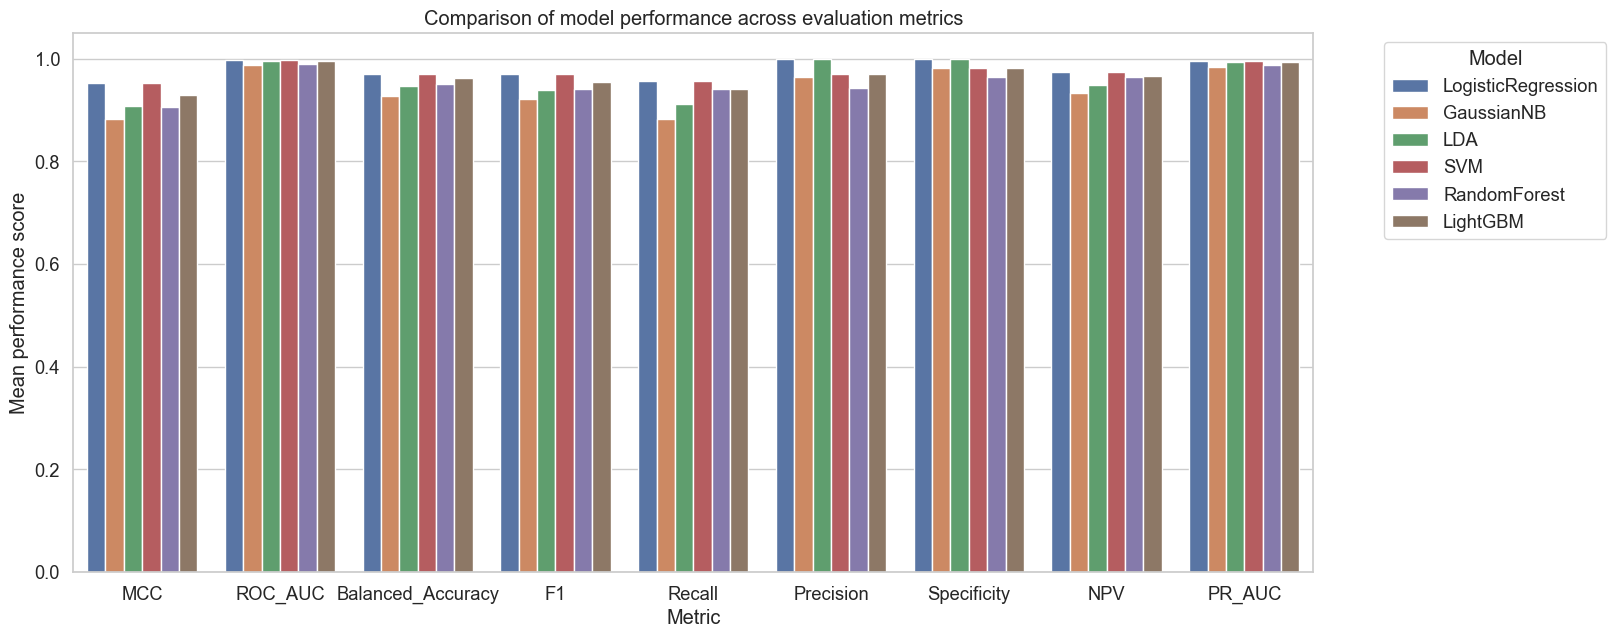

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/rncv_summary_results.csv")

df_long = df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="MeanScore"
)

sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(16, 7))

ax = sns.barplot(
    data=df_long,
    x="Metric",
    y="MeanScore",
    hue="Model"
)

ax.set_ylabel("Mean performance score")
ax.set_xlabel("Metric")
ax.set_title("Comparison of model performance across evaluation metrics")

plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

# SAVE (before show!)
plt.savefig(
    "../images/model_comparison_barplot.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


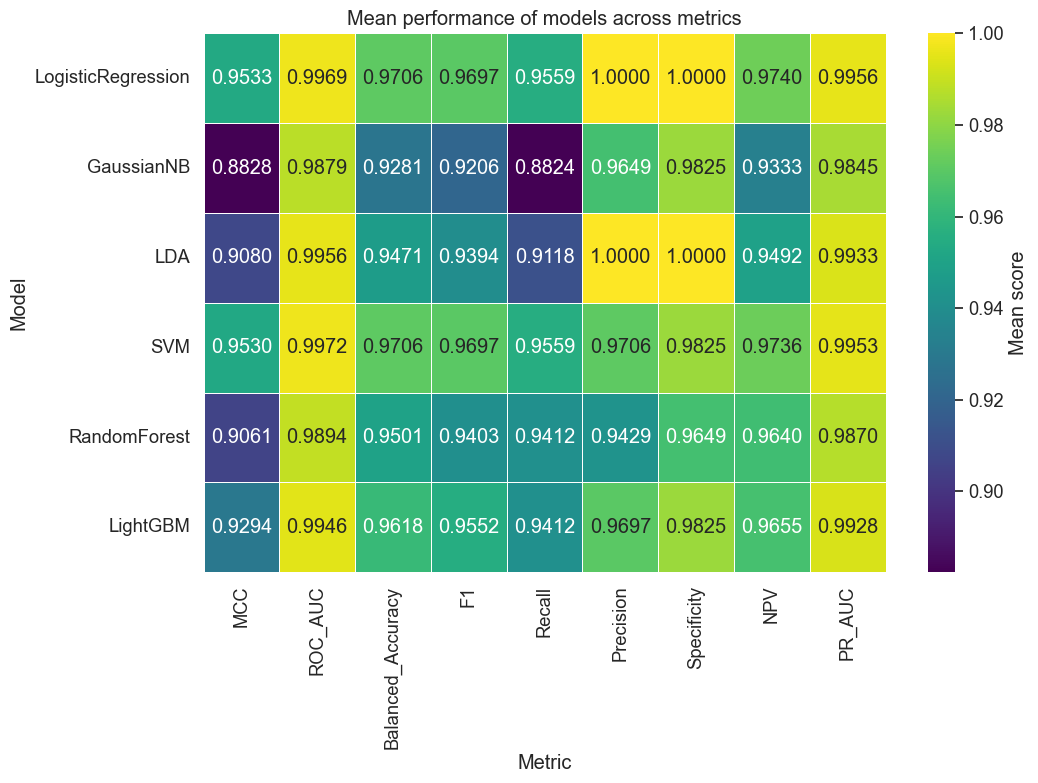

In [ ]:
plt.figure(figsize=(11, 7))

pivot = df.set_index("Model")

ax = sns.heatmap(
    pivot ,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    cbar_kws={"label": "Mean score"},
    linewidths=0.5
)

ax.set_title("Mean performance of models across metrics")
ax.set_xlabel("Metric")
ax.set_ylabel("Model")

plt.savefig(
    "../images/model_comparison_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


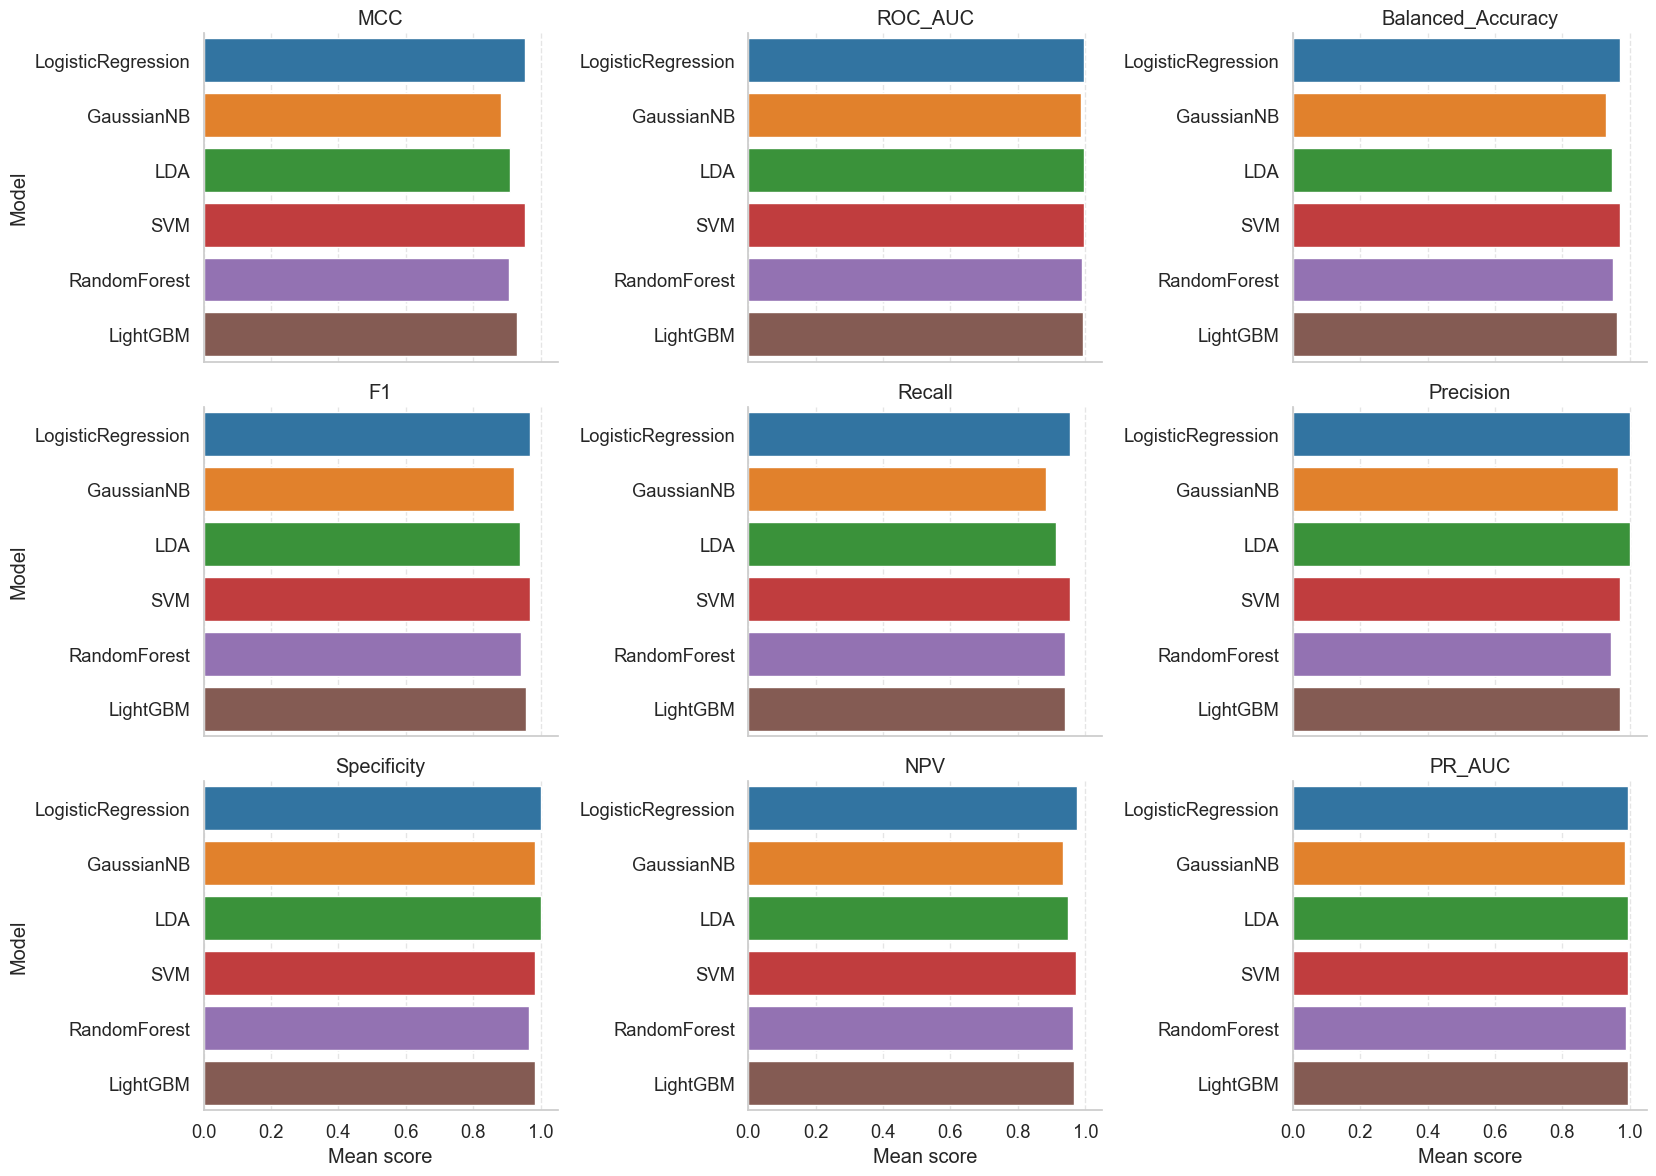

In [16]:
palette = sns.color_palette("tab10", n_colors=df["Model"].nunique())

g = sns.catplot(
    data=df_long,
    y="Model",
    x="MeanScore",
    hue="Model",
    palette=palette,
    col="Metric",
    kind="bar",
    col_wrap=3,
    height=4,
    aspect=1.4,
    sharey=False,
    legend=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Mean score", "Model")

# Improve readability
for ax in g.axes.flatten():
    ax.grid(True, axis="x", linestyle="--", alpha=0.5)

# Save
g.figure.savefig(
    "../images/model_comparison_faceted_horizontal_colored.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()